In [1]:
library(readr)
library(broom)
library(dplyr)
library(ggplot2)
library(scales)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




In [2]:
mydata <- read_csv('out/df_translation_associations_df.csv', show_col_types = FALSE)
head(mydata, 5)

species_unique,strain_unique,assay_unique,tested_both_sexes,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,3,0,0
1,1,4,0,0
2,4,4,1,0
1,1,2,0,0
2,0,2,0,0


In [3]:
mydata$target <- as.factor(mydata$target)


In [4]:
#mydata$tested_both_sexes_binary <- as.factor(mydata$tested_both_sexes)
mydata$tested_both_sexes_binary <- mydata$tested_both_sexes

In [5]:
#mydata$species_unique <- as.factor(mydata$species_unique)

In [6]:
str(mydata$tested_both_sexes_binary)

 num [1:5231] 0 0 1 0 0 0 0 0 1 1 ...


In [7]:
summary(mydata)


 species_unique  strain_unique     assay_unique   tested_both_sexes target  
 Min.   :0.000   Min.   : 0.000   Min.   :0.000   Min.   :0.0000    0:2110  
 1st Qu.:1.000   1st Qu.: 0.000   1st Qu.:2.000   1st Qu.:0.0000    1:3121  
 Median :1.000   Median : 1.000   Median :2.000   Median :0.0000            
 Mean   :1.607   Mean   : 1.754   Mean   :2.552   Mean   :0.4426            
 3rd Qu.:2.000   3rd Qu.: 2.000   3rd Qu.:4.000   3rd Qu.:1.0000            
 Max.   :8.000   Max.   :41.000   Max.   :5.000   Max.   :1.0000            
 tested_both_sexes_binary
 Min.   :0.0000          
 1st Qu.:0.0000          
 Median :0.0000          
 Mean   :0.4426          
 3rd Qu.:1.0000          
 Max.   :1.0000          

In [8]:
table(mydata$species_unique)


   0    1    2    3    4    5    6    7    8 
 292 2633 1555  486  171   56   29    6    3 

In [9]:
str(mydata)

spc_tbl_ [5,231 × 6] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ species_unique          : num [1:5231] 1 1 2 1 2 1 2 1 2 1 ...
 $ strain_unique           : num [1:5231] 3 1 4 1 0 1 4 4 0 1 ...
 $ assay_unique            : num [1:5231] 3 4 4 2 2 1 3 4 4 3 ...
 $ tested_both_sexes       : num [1:5231] 0 0 1 0 0 0 0 0 1 1 ...
 $ target                  : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ tested_both_sexes_binary: num [1:5231] 0 0 1 0 0 0 0 0 1 1 ...
 - attr(*, "spec")=
  .. cols(
  ..   species_unique = col_double(),
  ..   strain_unique = col_double(),
  ..   assay_unique = col_double(),
  ..   tested_both_sexes = col_double(),
  ..   target = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


In [10]:
mylogit <- glm(target ~ species_unique, data = mydata, family = "binomial")
summary(mylogit)


Call:
glm(formula = target ~ species_unique, family = "binomial", data = mydata)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)     0.14489    0.05347   2.710  0.00674 ** 
species_unique  0.15519    0.02893   5.364 8.13e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 7055.1  on 5230  degrees of freedom
Residual deviance: 7025.3  on 5229  degrees of freedom
AIC: 7029.3

Number of Fisher Scoring iterations: 4


In [11]:
mylogit <- glm(target ~ assay_unique, data = mydata, family = "binomial")
#


In [12]:
mydata

species_unique,strain_unique,assay_unique,tested_both_sexes,target,tested_both_sexes_binary
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,3,3,0,0,0
1,1,4,0,0,0
2,4,4,1,0,1
1,1,2,0,0,0
2,0,2,0,0,0
1,1,1,0,0,0
2,4,3,0,0,0
1,4,4,0,0,0
2,0,4,1,0,1


## fit all

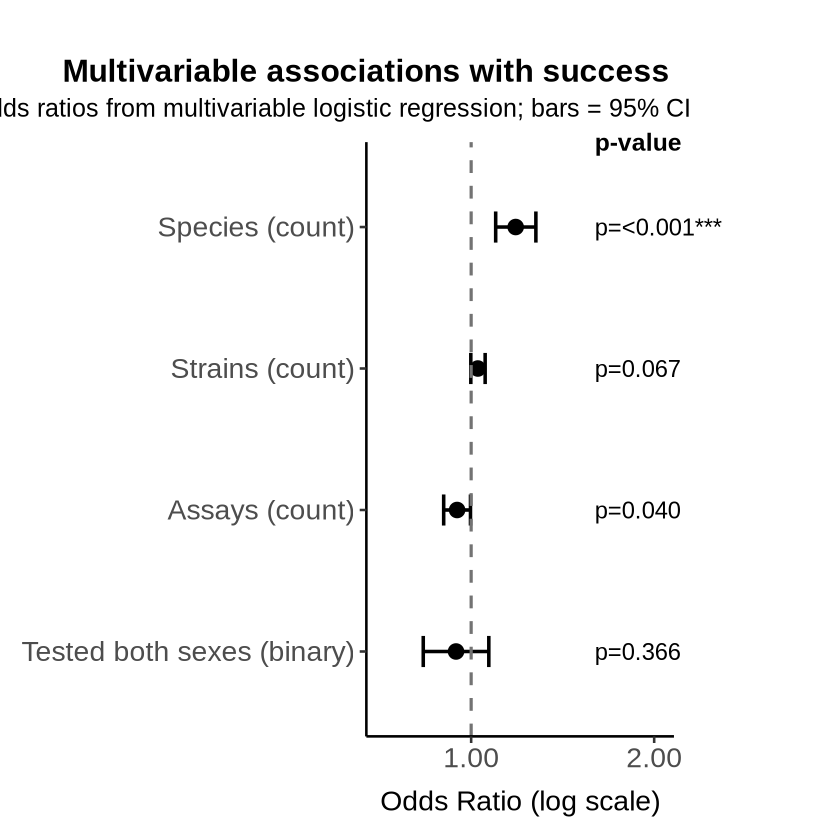

In [37]:
library(dplyr)
library(broom)
library(ggplot2)
library(scales)

# ---- Pretty labels ----
label_map <- c(
  species_unique = "Species (count)",
  strain_unique  = "Strains (count)",
  assay_unique   = "Assays (count)",
  tested_both_sexes_binary = "Tested both sexes (binary)"
)

# ---- Fit multivariable logistic regression ----
mylogit <- glm(
  target ~ species_unique + strain_unique + assay_unique + tested_both_sexes_binary,
  data = mydata,
  family = binomial()
)

# ---- Tidy + transform to OR ----
plot_df <- tidy(mylogit, conf.int = TRUE) %>%
  filter(term != "(Intercept)") %>%
  mutate(
    predictor = gsub("`", "", term),
    predictor_lab = recode(predictor, !!!label_map),

    or = exp(estimate),
    lo = exp(conf.low),
    hi = exp(conf.high),

    sig = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      TRUE            ~ ""
    ),
    p_fmt = ifelse(p.value < 0.001, "<0.001", sprintf("%.3f", p.value)),
    p_lab = paste0("p=", p_fmt, sig)
  ) %>%
  arrange(or) %>%
  mutate(predictor_lab = factor(predictor_lab, levels = predictor_lab))

# ---- Right-side p-value column positions ----
x_pcol  <- max(plot_df$hi, na.rm = TRUE) * 1.25
x_right <- max(plot_df$hi, na.rm = TRUE) * 1.60

# ---- Plot ----
ggplot(plot_df, aes(x = or, y = predictor_lab)) +
  geom_errorbarh(aes(xmin = lo, xmax = hi),
                 height = 0.22, linewidth = 1.0) +
  geom_point(size = 4.0) +
  geom_vline(xintercept = 1,
             linetype = "dashed",
             linewidth = 0.9,
             colour = "grey45") +

  # p-value column
  geom_text(aes(x = x_pcol, label = p_lab),
            hjust = 0, size = 5.0) +
  annotate(
    "text",
    x = x_pcol,
    y = length(levels(plot_df$predictor_lab)) + 0.6,
    label = "p-value",
    hjust = 0,
    size = 5.2,
    fontface = "bold"
  ) +

  scale_x_log10(
    breaks = c(0.25, 0.5, 1, 2, 4, 8),
    labels = label_number(accuracy = 0.01)
  ) +
  coord_cartesian(
    xlim = c(min(plot_df$lo, na.rm = TRUE) * 0.85, x_right),
    clip = "off"
  ) +

  labs(
    x = "Odds Ratio (log scale)",
    y = NULL,
    title = "Multivariable associations with success",
    subtitle = "Adjusted odds ratios from multivariable logistic regression; bars = 95% CI"
  ) +

    theme_classic(base_size = 16) +
    theme(
      plot.title.position = "plot",
    
      plot.title = element_text(face = "bold", size = 19, hjust = 0.9, margin = margin(b = 6)),
      plot.subtitle = element_text(size = 15, hjust = 0.9, margin = margin(b = 12)),
    
      axis.text.y   = element_text(size = 17),
      axis.text.x   = element_text(size = 17),
      axis.title.x  = element_text(size = 17, margin = margin(t = 10)),
    
      plot.margin   = margin(t = 36, r = 100, b = 14, l = 14)
    )


ggsave(
  filename = "viz/multivariable_effects.pdf",
  plot = last_plot(),
  width = 10,
  height = 5.8,
  units = "in",
  device = cairo_pdf
)


In [40]:
# keep species numerical
# test separately each of the characteristics
# vs adjusted -> in the context of the remaining variables
# factor -> each stage has can have its own effect
# if we keep them numeric -> forced linearly
# try factor taken as reference the 1 values -> to test if the effect is linear
# causality != regression unless we are looking at the causal factors 
# if linear -> interpretation -> how much would the log odds change if the predictor is increase with one unit and all other predictors remain the same
# todo : show linear relationship !!! increasing species count higher 

## fit individual

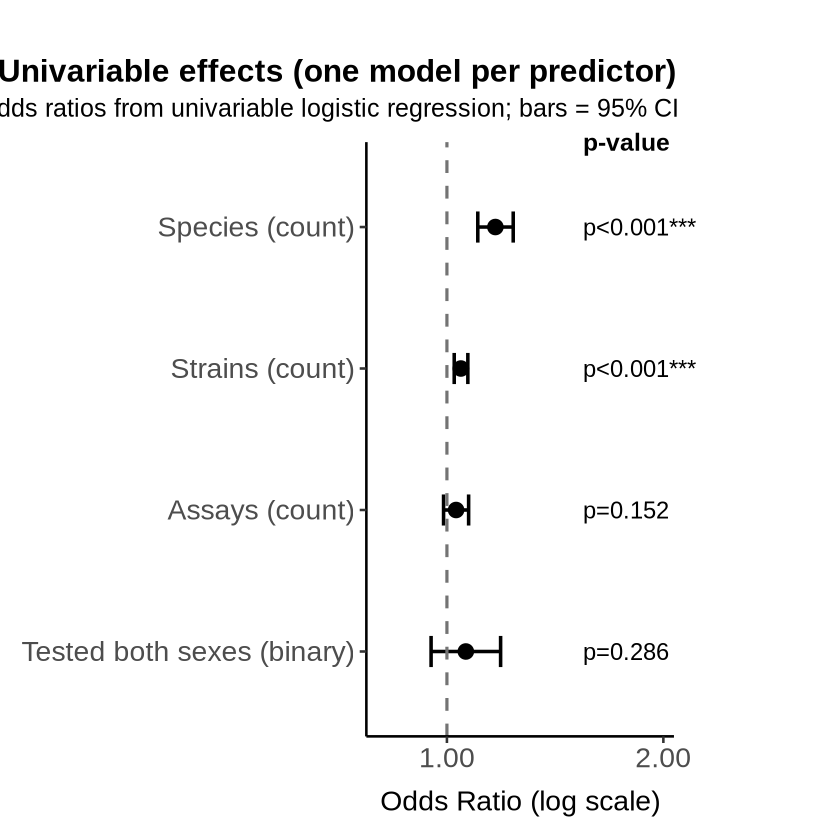

In [43]:
library(dplyr)
library(purrr)
library(broom)
library(ggplot2)
library(scales)
library(stringr)

vars <- c("species_unique", "strain_unique", "assay_unique", "tested_both_sexes_binary")

res <- map_dfr(vars, function(v) {
  m <- glm(as.formula(paste("target ~", v)), data = mydata, family = binomial())
  tidy(m, conf.int = TRUE) |>
    filter(term != "(Intercept)") |>
    transmute(
      predictor = v,
      estimate, conf.low, conf.high, p.value,
      or = exp(estimate),
      lo = exp(conf.low),
      hi = exp(conf.high),
      p_lab = case_when(
        p.value < 0.001 ~ "p<0.001***",
        p.value < 0.01  ~ paste0("p=", sprintf("%.3f", p.value), "**"),
        p.value < 0.05  ~ paste0("p=", sprintf("%.3f", p.value), "*"),
        TRUE            ~ paste0("p=", sprintf("%.3f", p.value))
      )
    )
})

label_map <- c(
  species_unique = "Species (count)",
  strain_unique  = "Strains (count)",
  assay_unique   = "Assays (count)",
  tested_both_sexes_binary = "Tested both sexes (binary)"
)

res <- res |>
  mutate(predictor_lab = recode(predictor, !!!label_map))

label_order <- unname(recode(vars, !!!label_map))

res <- res |>
  mutate(predictor_lab = factor(predictor_lab, levels = rev(label_order)))

# Position for p-values (one column to the right)
x_pcol  <- max(res$hi, na.rm = TRUE) * 1.25
x_right <- max(res$hi, na.rm = TRUE) * 1.60

p <- ggplot(res, aes(x = or, y = predictor_lab)) +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.22, linewidth = 1.0) +
  geom_point(size = 4.0) +
  geom_vline(xintercept = 1, linetype = "dashed", linewidth = 0.9, colour = "grey45") +

  # p-value column
  geom_text(aes(x = x_pcol, label = p_lab), hjust = 0, size = 5.0) +
  annotate(
    "text",
    x = x_pcol,
    y = length(levels(res$predictor_lab)) + 0.6,
    label = "p-value",
    hjust = 0,
    size = 5.2,
    fontface = "bold"
  ) +

  scale_x_log10(
    breaks = c(0.25, 0.5, 1, 2, 4, 8),
    labels = label_number(accuracy = 0.01)
  ) +
  coord_cartesian(
    xlim = c(min(res$lo, na.rm = TRUE) * 0.85, x_right),
    clip = "off"
  ) +
  labs(
    x = "Odds Ratio (log scale)",
    y = NULL,
    title = "Univariable effects (one model per predictor)",
    subtitle = "Odds ratios from univariable logistic regression; bars = 95% CI"
  ) +

  theme_classic(base_size = 16) +
  theme(
    # Prevent subtitle cropping AND avoid the "pulled left" look
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 19, hjust = 0.9, margin = margin(b = 6)),
    plot.subtitle = element_text(size = 15, hjust = 0.9, margin = margin(b = 12)),

    # Bigger axis labels
    axis.text.y  = element_text(size = 17),
    axis.text.x  = element_text(size = 17),
    axis.title.x = element_text(size = 17, margin = margin(t = 10)),

    # More top room so subtitle never clips; right room for p column
    plot.margin = margin(t = 36, r = 100, b = 14, l = 14)
  )

print(p)

ggsave(
  filename = "viz/univariable_effects.pdf",
  plot = p,
  width = 10,
  height = 5.8,
  units = "in",
  device = cairo_pdf
)
